In [1]:
#from src.database import get_connection, create_schemas, create_raw_tables, load_raw_data

In [2]:
%run ../src/database.py

# 1. Create connection
conn = get_connection()

# 2. Set up the database (schemas and tables) from scratch
create_schemas(conn)
create_raw_tables(conn)

# 3. Now load data from parquet files
load_raw_data(conn)

print("Database is ready and data has been loaded!")

Database is ready and data has been loaded!


In [3]:
import duckdb
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno

# Connecting to the database (setting read_only=True reduces the risk of 'File in use' errors)
conn = duckdb.connect('../data/weather_pipeline.duckdb', read_only=False)

# Fetching all raw data from the database table
df = conn.execute("SELECT * FROM raw.weather_daily").df()

# Converting the date column to the correct datetime format
df['date'] = pd.to_datetime(df['date'])

print(f"Total row count: {len(df)}")
df.head()

Total row count: 85


,city,date,temperature_2m_mean,et0_fao_evapotranspiration_sum,sunshine_duration,shortwave_radiation_sum,relative_humidity_2m_mean,surface_pressure_mean,precipitation_sum,precipitation_hours,wind_speed_10m_max,cloud_cover_mean,wind_gusts_10m_mean,soil_moisture_0_to_7cm_mean,data_type
0,Baki,2026-04-13,10.950000,2.437522,32400.000000,18.049999,82.486885,1015.722656,6.7,5.0,30.360830,75.750000,44.744991,0.260292,historical
1,Baki,2026-04-14,11.312499,2.305472,33141.066406,15.010000,79.314529,1021.701904,2.4,13.0,15.856354,79.000000,22.964998,0.283333,historical
2,Baki,2026-04-15,11.702085,3.136395,41735.414062,20.240000,69.572823,1024.161987,0.3,3.0,15.484185,47.250000,28.199997,0.277208,historical
3,Baki,2026-04-16,13.097917,3.106966,42755.191406,19.440001,65.637993,1023.956787,0.0,0.0,12.362475,20.416666,14.085001,0.260625,historical
4,Baki,2026-04-17,12.995834,3.021810,42742.210938,21.790001,80.436111,1024.379028,0.0,0.0,16.036171,22.750000,25.874998,0.239250,historical


In [5]:
#df = conn.execute("SELECT * FROM read_parquet('../data/raw/*.parquet') LIMIT 0").df()
#print(df.columns)

<Axes: >

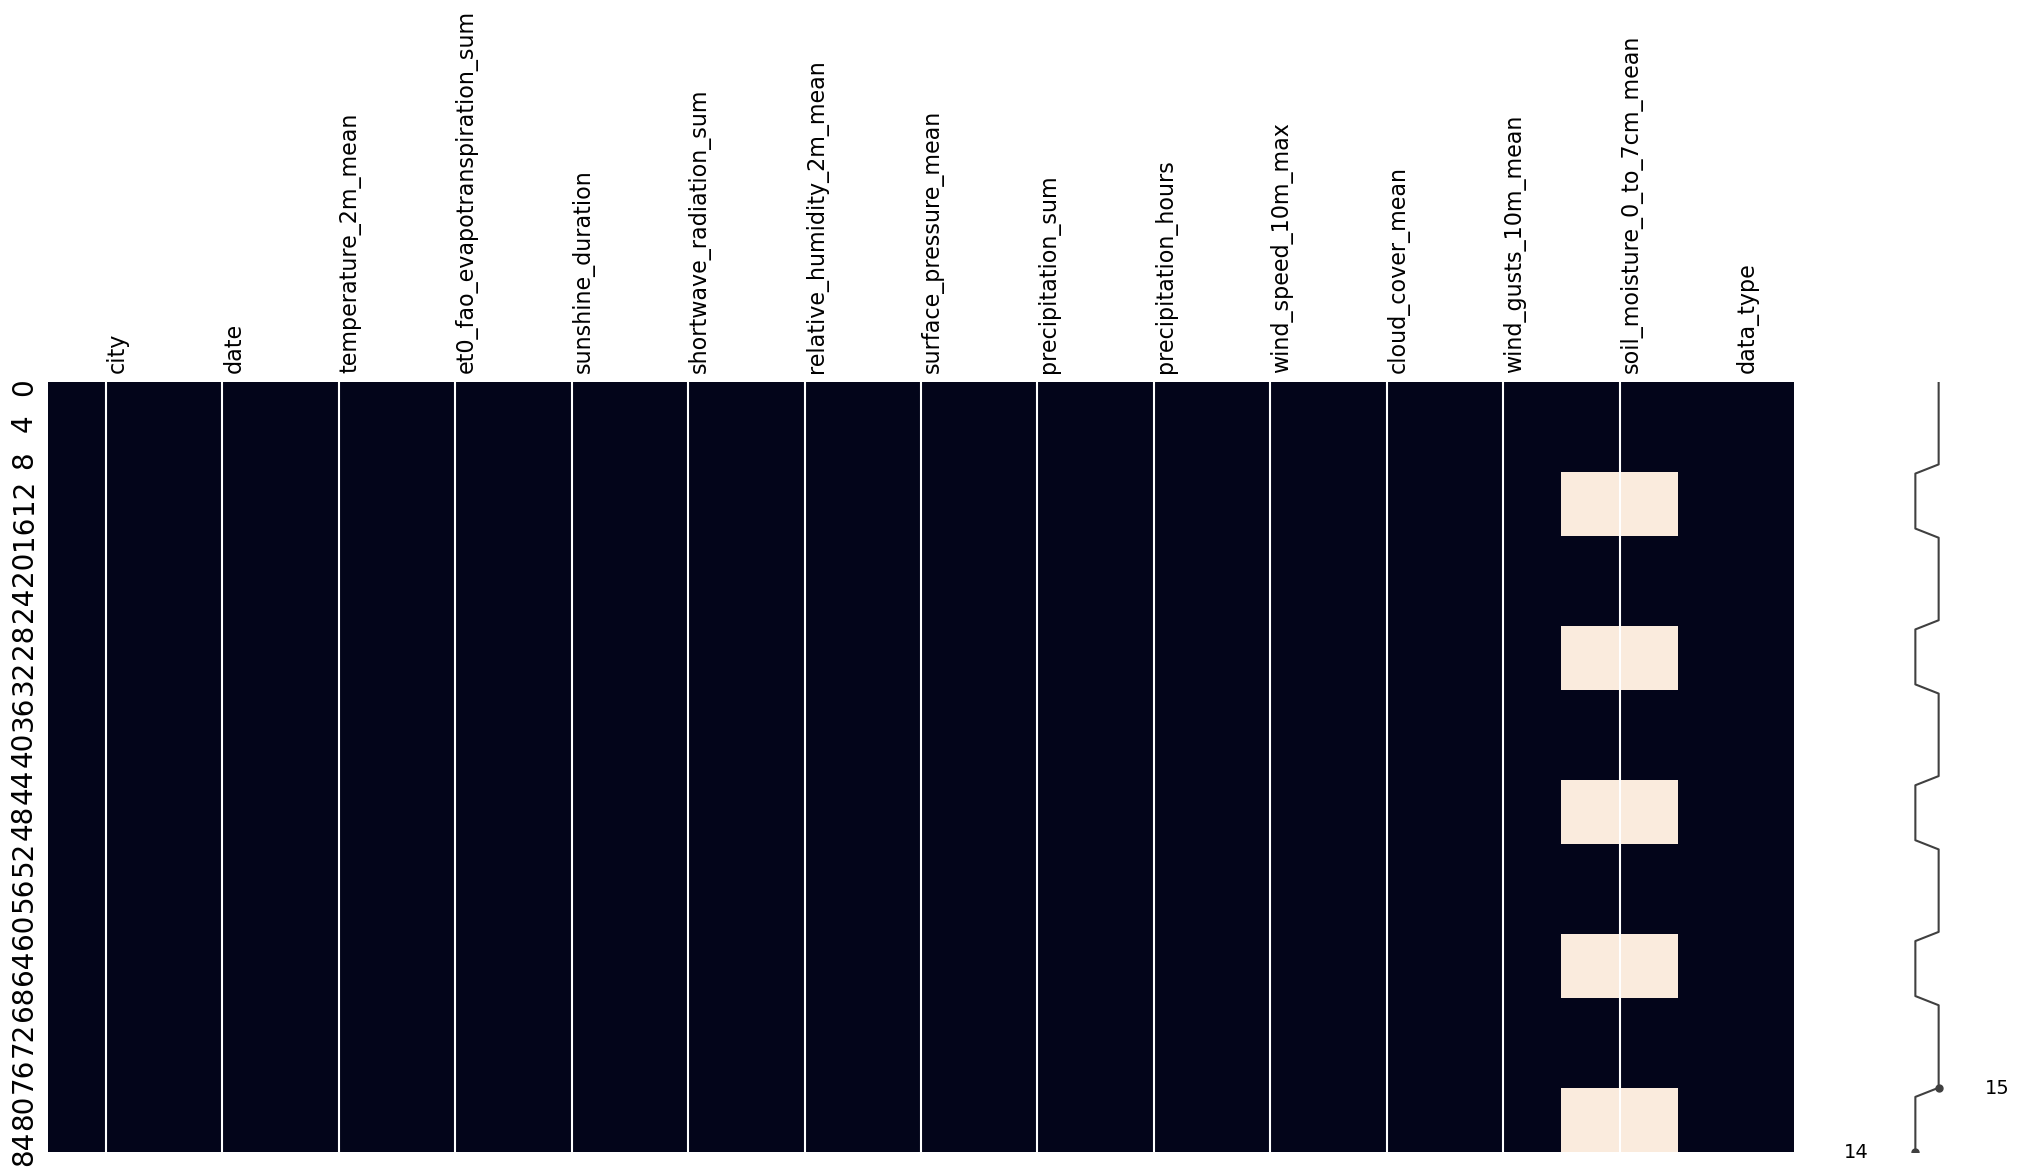

In [4]:
df.isna().mean().sort_values(ascending=False)*100
msno.matrix(df)
sns.heatmap(df.isna(), cbar=False)


temperature_2m_mean → 7 outliers


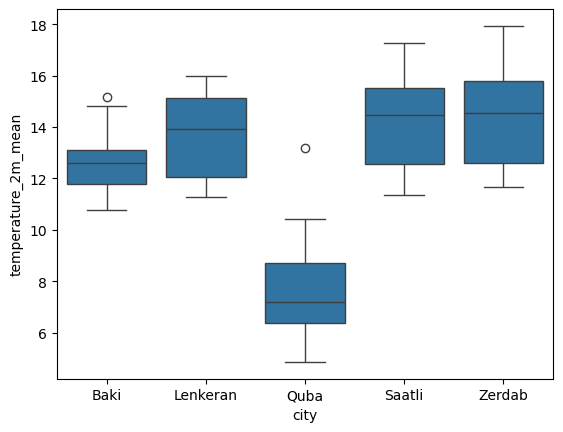

et0_fao_evapotranspiration_sum → 0 outliers


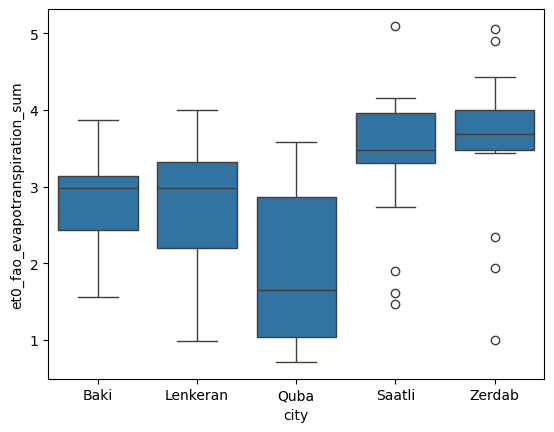

sunshine_duration → 0 outliers


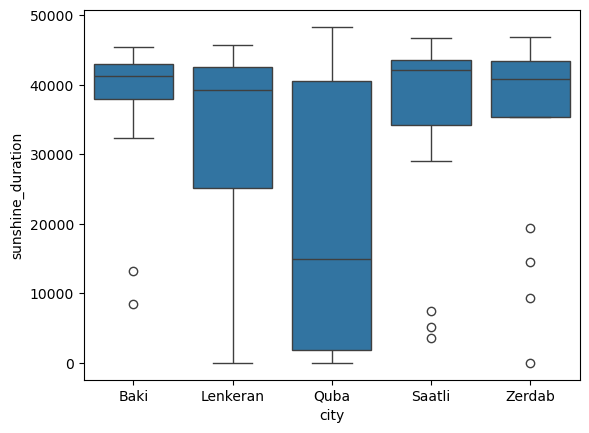

shortwave_radiation_sum → 0 outliers


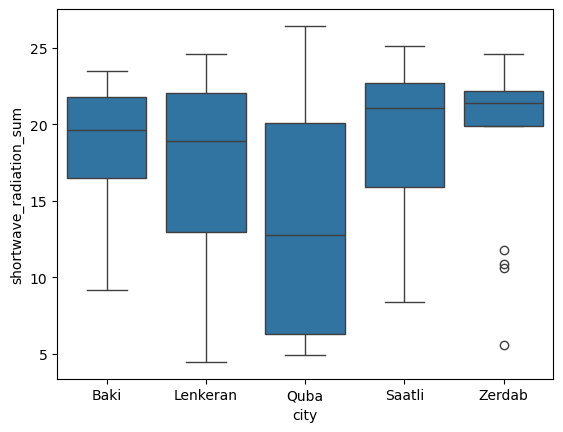

relative_humidity_2m_mean → 0 outliers


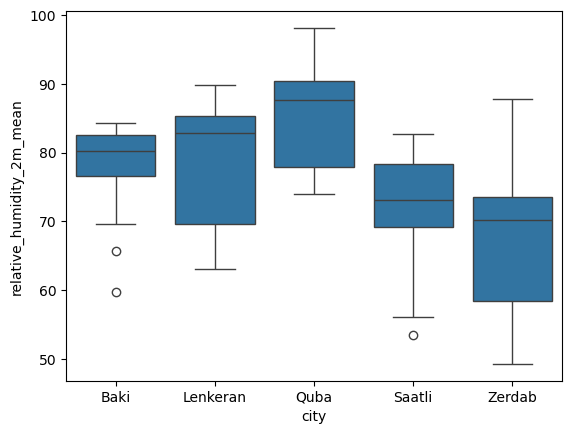

surface_pressure_mean → 17 outliers


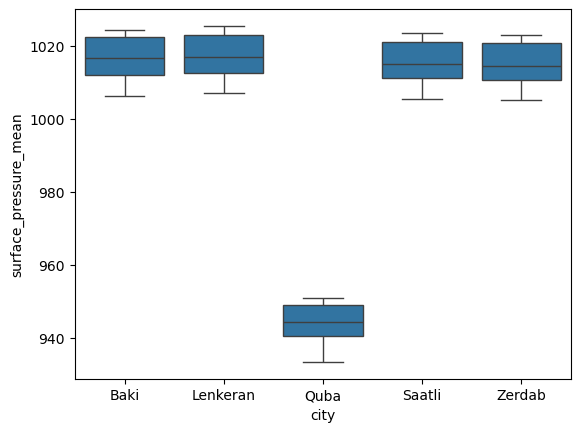

precipitation_sum → 17 outliers


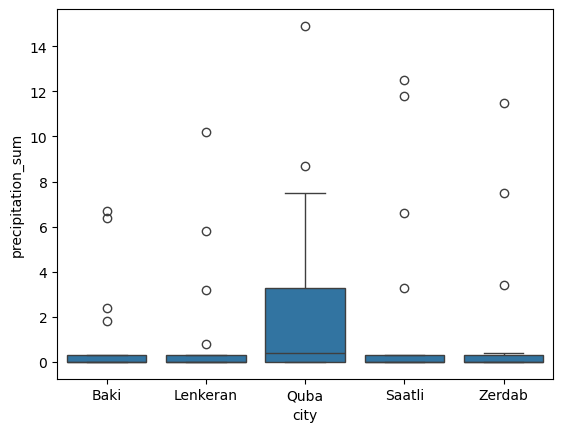

precipitation_hours → 7 outliers


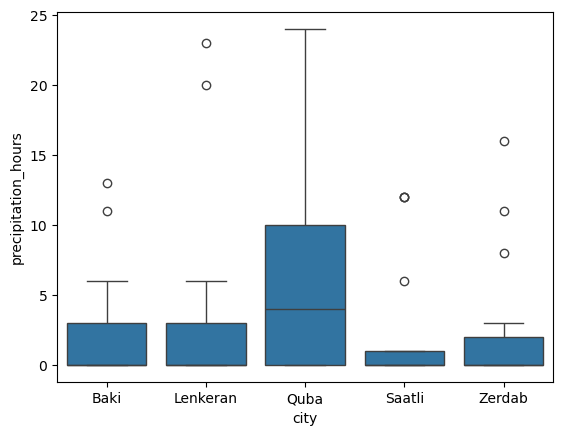

wind_speed_10m_max → 5 outliers


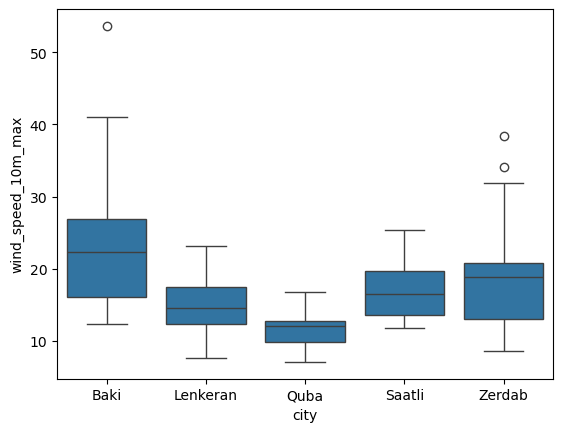

cloud_cover_mean → 0 outliers


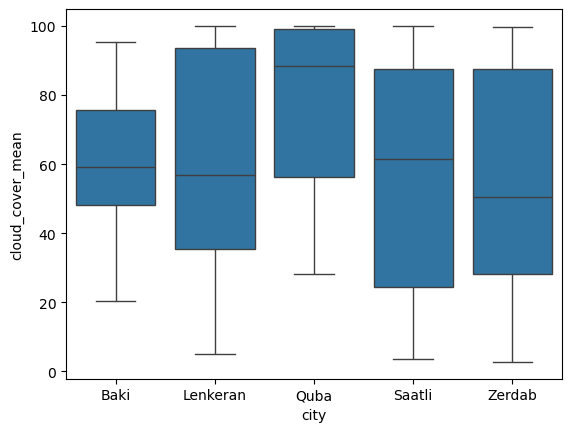

wind_gusts_10m_mean → 5 outliers


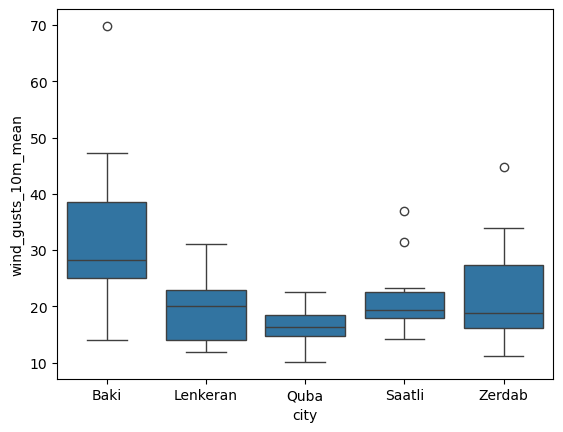

soil_moisture_0_to_7cm_mean → 0 outliers


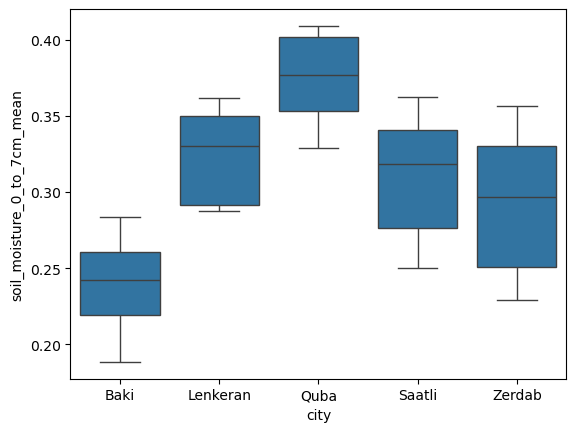

In [5]:
numeric_cols = df.select_dtypes(include=["float64", "int64"]).columns

for col in numeric_cols:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    print(col, "→", outliers, "outliers")
    sns.boxplot(x="city", y=col, data=df)
    plt.show()


In [6]:
(df.groupby("city")
   .apply(lambda x: x['date'].diff().dt.days.value_counts())
)


C:\Users\ASUS\AppData\Local\Temp\ipykernel_20400\3471410882.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x['date'].diff().dt.days.value_counts())


date,1.0
city,
Baki,16
Lenkeran,16
Quba,16
Saatli,16
Zerdab,16


In [7]:
pd.date_range(df['date'].min(), df['date'].max()).difference(df['date'])


DatetimeIndex([], dtype='datetime64[ns]', freq='D')

In [8]:
cutoff_date = df['date'].max() - pd.Timedelta(days=6)  # son 7 gün forecast-dır
hist_df = df[df['date'] < cutoff_date]
forecast_df = df[df['date'] >= cutoff_date]


In [9]:
common_dates = df.groupby('city')['date'].apply(lambda x: x.duplicated().sum())
print(common_dates)


city
Baki        0
Lenkeran    0
Quba        0
Saatli      0
Zerdab      0
Name: date, dtype: int64


In [10]:
for col in numeric_cols:
    df['dup_count'] = (df[col] == df[col].shift()).astype(int)
    if df['dup_count'].rolling(5).sum().max() > 4:
        print(col, "→ more sequence")


precipitation_sum → more sequence
precipitation_hours → more sequence


In [23]:
df['precipitation_sum']

0     6.7
1     2.4
2     0.3
3     0.0
4     0.0
     ... 
80    0.0
81    0.0
82    0.0
83    0.9
84    0.0
Name: precipitation_sum, Length: 85, dtype: float64

In [7]:
%run ../src/cleaning.py

In [8]:
cleaned_df = clean_raw_to_staging(conn)
cleaned_df.head(10)



🔄 Cleaning data from raw.weather_daily ...
📥 Raw data loaded: 85 rows, 15 columns

📅 Date continuity summary:
       city start_date   end_date  expected_days  actual_days  missing_days  \
0      Baki 2026-04-13 2026-04-29             17           17             0   
1  Lenkeran 2026-04-13 2026-04-29             17           17             0   
2      Quba 2026-04-13 2026-04-29             17           17             0   
3    Saatli 2026-04-13 2026-04-29             17           17             0   
4    Zerdab 2026-04-13 2026-04-29             17           17             0   

  missing_list  
0           []  
1           []  
2           []  
3           []  
4           []  

✅ Cleaned data written to staging.weather_daily
📊 Sample of cleaned data:
city       date  temperature_2m_mean  et0_fao_evapotranspiration_sum  sunshine_duration  shortwave_radiation_sum  relative_humidity_2m_mean  surface_pressure_mean  precipitation_sum  precipitation_hours  wind_speed_10m_max  cloud_cover_me

C:\Users\ASUS\iboo\IronHack\week_ML\Mid-project\mid_4\m5-project-weather-pipeline\src\cleaning.py:15: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[target_cols] = df[target_cols].fillna(method="ffill")


,city,date,temperature_2m_mean,et0_fao_evapotranspiration_sum,sunshine_duration,shortwave_radiation_sum,relative_humidity_2m_mean,surface_pressure_mean,precipitation_sum,precipitation_hours,wind_speed_10m_max,cloud_cover_mean,wind_gusts_10m_mean,soil_moisture_0_to_7cm_mean,data_type
0,Baki,2026-04-13,10.950000,2.437522,32400.000000,18.049999,82.486885,1015.722656,6.7,5.0,30.360830,75.750000,44.744991,0.260292,historical
1,Baki,2026-04-14,11.312499,2.305472,33141.066406,15.010000,79.314529,1021.701904,2.4,13.0,15.856354,79.000000,22.964998,0.283333,historical
2,Baki,2026-04-15,11.702085,3.136395,41735.414062,20.240000,69.572823,1024.161987,0.3,3.0,15.484185,47.250000,28.199997,0.277208,historical
3,Baki,2026-04-16,13.097917,3.106966,42755.191406,19.440001,65.637993,1023.956787,0.0,0.0,12.362475,20.416666,14.085001,0.260625,historical
4,Baki,2026-04-17,12.995834,3.021810,42742.210938,21.790001,80.436111,1024.379028,0.0,0.0,16.036171,22.750000,25.874998,0.239250,historical
5,Baki,2026-04-18,13.668750,2.861732,43815.843750,22.580000,83.649406,1016.915588,0.0,0.0,22.350464,27.541666,38.280003,0.212958,historical
6,Baki,2026-04-19,15.177083,3.267373,41231.125000,21.450001,80.289223,1006.191345,0.1,1.0,20.803045,51.625000,34.079998,0.188708,historical
7,Baki,2026-04-20,13.847917,2.064010,8520.239258,9.200000,76.577911,1011.642517,1.8,6.0,24.725605,95.208336,47.235001,0.188417,historical
8,Baki,2026-04-21,10.787499,1.553613,13218.458984,9.220000,83.323708,1015.477234,6.4,11.0,22.158285,75.750000,38.565002,0.244083,historical
9,Baki,2026-04-22,13.112499,3.127617,43021.062500,20.930000,80.909668,1013.233398,0.0,0.0,18.501513,51.833332,25.094997,0.240625,historical


In [9]:
cleaned_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85 entries, 0 to 84
Data columns (total 15 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   city                            85 non-null     object        
 1   date                            85 non-null     datetime64[us]
 2   temperature_2m_mean             85 non-null     float64       
 3   et0_fao_evapotranspiration_sum  85 non-null     float64       
 4   sunshine_duration               85 non-null     float64       
 5   shortwave_radiation_sum         85 non-null     float64       
 6   relative_humidity_2m_mean       85 non-null     float64       
 7   surface_pressure_mean           85 non-null     float64       
 8   precipitation_sum               85 non-null     float64       
 9   precipitation_hours             85 non-null     float64       
 10  wind_speed_10m_max              85 non-null     float64       
 11  cloud_co

In [22]:
%run ../src/features.py
created_features_df=create_features(conn)
created_features_df.head()

🔧 Generating features from staging.weather_daily ...
✅ Features computed: day_of_year, precip_sum_7d, prev_soil_moisture

Data now has 85 rows and 18 columns.

📊 Example of engineered data:
city       date  temperature_2m_mean  et0_fao_evapotranspiration_sum  sunshine_duration  shortwave_radiation_sum  relative_humidity_2m_mean  surface_pressure_mean  precipitation_sum  precipitation_hours  wind_speed_10m_max  cloud_cover_mean  wind_gusts_10m_mean  soil_moisture_0_to_7cm_mean  data_type  day_of_year  precip_sum_7d  prev_soil_moisture
Baki 2026-04-13            10.950000                        2.437522       32400.000000                18.049999                  82.486885            1015.722656                6.7                  5.0           30.360830         75.750000            44.744991                     0.260292 historical          103            6.7                 NaN
Baki 2026-04-14            11.312499                        2.305472       33141.066406                15.0100

,city,date,temperature_2m_mean,et0_fao_evapotranspiration_sum,sunshine_duration,shortwave_radiation_sum,relative_humidity_2m_mean,surface_pressure_mean,precipitation_sum,precipitation_hours,wind_speed_10m_max,cloud_cover_mean,wind_gusts_10m_mean,soil_moisture_0_to_7cm_mean,data_type,day_of_year,precip_sum_7d,prev_soil_moisture
0,Baki,2026-04-13,10.950000,2.437522,32400.000000,18.049999,82.486885,1015.722656,6.7,5.0,30.360830,75.750000,44.744991,0.260292,historical,103,6.7,NaN
1,Baki,2026-04-14,11.312499,2.305472,33141.066406,15.010000,79.314529,1021.701904,2.4,13.0,15.856354,79.000000,22.964998,0.283333,historical,104,9.1,0.260292
2,Baki,2026-04-15,11.702085,3.136395,41735.414062,20.240000,69.572823,1024.161987,0.3,3.0,15.484185,47.250000,28.199997,0.277208,historical,105,9.4,0.283333
3,Baki,2026-04-16,13.097917,3.106966,42755.191406,19.440001,65.637993,1023.956787,0.0,0.0,12.362475,20.416666,14.085001,0.260625,historical,106,9.4,0.277208
4,Baki,2026-04-17,12.995834,3.021810,42742.210938,21.790001,80.436111,1024.379028,0.0,0.0,16.036171,22.750000,25.874998,0.239250,historical,107,9.4,0.260625


In [24]:
created_features_df[created_features_df['city']=='Baki']

,city,date,temperature_2m_mean,et0_fao_evapotranspiration_sum,sunshine_duration,shortwave_radiation_sum,relative_humidity_2m_mean,surface_pressure_mean,precipitation_sum,precipitation_hours,wind_speed_10m_max,cloud_cover_mean,wind_gusts_10m_mean,soil_moisture_0_to_7cm_mean,data_type,day_of_year,precip_sum_7d,prev_soil_moisture
0,Baki,2026-04-13,10.950000,2.437522,32400.000000,18.049999,82.486885,1015.722656,6.7,5.0,30.360830,75.750000,44.744991,0.260292,historical,103,6.7,NaN
1,Baki,2026-04-14,11.312499,2.305472,33141.066406,15.010000,79.314529,1021.701904,2.4,13.0,15.856354,79.000000,22.964998,0.283333,historical,104,9.1,0.260292
2,Baki,2026-04-15,11.702085,3.136395,41735.414062,20.240000,69.572823,1024.161987,0.3,3.0,15.484185,47.250000,28.199997,0.277208,historical,105,9.4,0.283333
3,Baki,2026-04-16,13.097917,3.106966,42755.191406,19.440001,65.637993,1023.956787,0.0,0.0,12.362475,20.416666,14.085001,0.260625,historical,106,9.4,0.277208
4,Baki,2026-04-17,12.995834,3.021810,42742.210938,21.790001,80.436111,1024.379028,0.0,0.0,16.036171,22.750000,25.874998,0.239250,historical,107,9.4,0.260625
5,Baki,2026-04-18,13.668750,2.861732,43815.843750,22.580000,83.649406,1016.915588,0.0,0.0,22.350464,27.541666,38.280003,0.212958,historical,108,9.4,0.239250
6,Baki,2026-04-19,15.177083,3.267373,41231.125000,21.450001,80.289223,1006.191345,0.1,1.0,20.803045,51.625000,34.079998,0.188708,historical,109,9.5,0.212958
7,Baki,2026-04-20,13.847917,2.064010,8520.239258,9.200000,76.577911,1011.642517,1.8,6.0,24.725605,95.208336,47.235001,0.188417,historical,110,4.6,0.188708
8,Baki,2026-04-21,10.787499,1.553613,13218.458984,9.220000,83.323708,1015.477234,6.4,11.0,22.158285,75.750000,38.565002,0.244083,historical,111,8.6,0.188417
9,Baki,2026-04-22,13.112499,3.127617,43021.062500,20.930000,80.909668,1013.233398,0.0,0.0,18.501513,51.833332,25.094997,0.240625,historical,112,8.3,0.244083
